# Descriptive Distributions


In [1]:
### headers
import numpy as np
from numpy import random

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

```{contents}
:local:
:depth: 2
```


This section uses numeric summaries, visualizations, and common distribution families to describe observed data and simulated outcomes.


In [2]:
### headers
import numpy as np
from numpy import random

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
tips = sns.load_dataset('tips')
tips                      ### size means number of ppl in the party

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [4]:
tips.shape       ### a dataframe has shape, which is a tuple

(244, 7)

## Descriptive Statistics

`df.describe()` gives you the descriptive statistics of the dataset.


In [5]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Key summaries for a numeric variable:

- Mean (average)  
- Median (middle value)  
- Standard deviation (typical distance from the mean)  
- IQR (middle 50% range)

Let's compute them for `total_bill`.


## Center: Mean vs Median


In [6]:
col = tips['total_bill']

summary = pd.DataFrame({
    'mean': [col.mean()],
    'median': [col.median()],
    'std (SD)': [col.std()],
    'IQR': [col.quantile(0.75) - col.quantile(0.25)]
})
summary

,mean,median,std (SD),IQR
0,19.785943,17.795,8.902412,10.78


## Visualizing One Variable

We'll use:
- Histogram (counts or density)
- Boxplot (median, quartiles, outliers)
- KDE / density curve (smoothed shape)

Interpretation checklist: **center / spread / shape / outliers**.


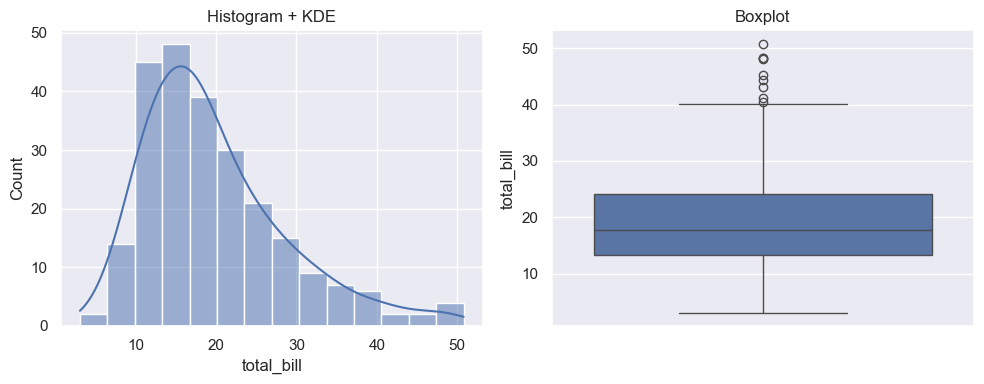

In [7]:
sns.set_theme()

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(tips, x='total_bill', kde=True, ax=axes[0])
axes[0].set_title('Histogram + KDE')

sns.boxplot(y=tips['total_bill'], ax=axes[1])
axes[1].set_title('Boxplot')

plt.tight_layout()

## Distributions



### Normal Distribution

A normal distribution—also called a **Gaussian** distribution—is a **symmetrical**, **bell-shaped** probability distribution **centered on the mean**, where most data points cluster around that mean with frequencies tapering off equally toward both extremes.

Key Properties: 

- Defined by its mean (μ) and standard deviation (σ).
- The `mean`, `median`, and `mode` are equal and located at the center.​
- Symmetrical: the left and right sides are mirror images.
- **68%** of data falls within 1 standard deviation, **95%** within 2, and **99.7%** within 3 standard deviations from the mean (“Empirical Rule”).​
- Frequently models real-world phenomena due to the Central Limit Theorem.

Example Applications:
- Heights of People: Human heights in a given population typically follow a normal distribution—most people are near the average height, with fewer extremely short or tall.​
- IQ Scores: Measured intelligence is designed to follow a normal curve, with an average of 100 and most people close to the average.​
- Measurement Errors: Repeated measurements of something (e.g., lengths, weights) often cluster around the true value, following a normal distribution.​
- Test Scores: Large-scale standardized test results (e.g., SAT, GRE) often approximate a normal distribution after some normalization.

Example        |  Mean (μ)  |  Standard Deviation (σ)  |  What is Measured         
---------------|------------|--------------------------|---------------------------
Adult heights  |  170 cm    |  10 cm                   |  Human height distribution
IQ scores      |  100       |  15                      |  Intelligence             
SAT scores     |  1050      |  200                     |  Standardized tests       

Let us use the `random` module in NumPy to explore. 


In [8]:
x = random.normal(size=(2, 3))
print(type(x))
print(x)

<class 'numpy.ndarray'>
[[ 0.09573473 -1.87315524  0.06039166]
 [-0.44040295 -1.02577375 -0.88463014]]


Now let's add mean and standard deviation (because this is a normal distribution). Here we are controlling the center and the spread of the distribution. Here in the normal function, the parameters `loc=` means the `mean` and `scale=` means the `standard deviation`, or SD.


In [9]:
### generate a random normal distribution of size 2X3 with mean at 1 and SD of 2

np.random.seed(42)
x = random.normal(loc=1, scale=2, size=(2, 3))
print(x)

[[1.99342831 0.7234714  2.29537708]
 [4.04605971 0.53169325 0.53172609]]


Time for some visualization. Note that we are using `height` and `aspect` (ratio) to control figure size because `distplot()` is a figure level function.


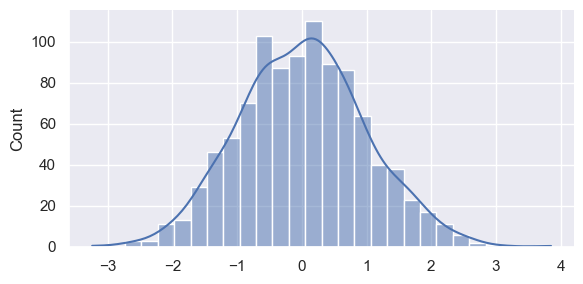

In [10]:
np.random.seed(42)
sns.displot(random.normal(size=1000), height=3, aspect=2,kde=True)

Here below is a KDE only plot. Note that we are controlling figure size by 

- `plt.figure(figsize)` 
- `dpi`


<Axes: ylabel='Density'>

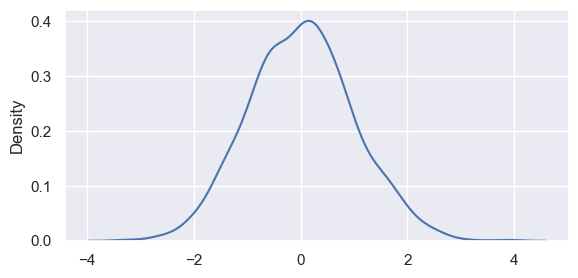

In [11]:
# random.seed(42)
np.random.seed(42)

plt.figure(figsize=(6.5, 3))
sns.kdeplot(random.normal(size=1000))

Now let's add `dpi` and `figuresize=` (because we are using `kdeplot`, which is an Axes level function) to control figure size.


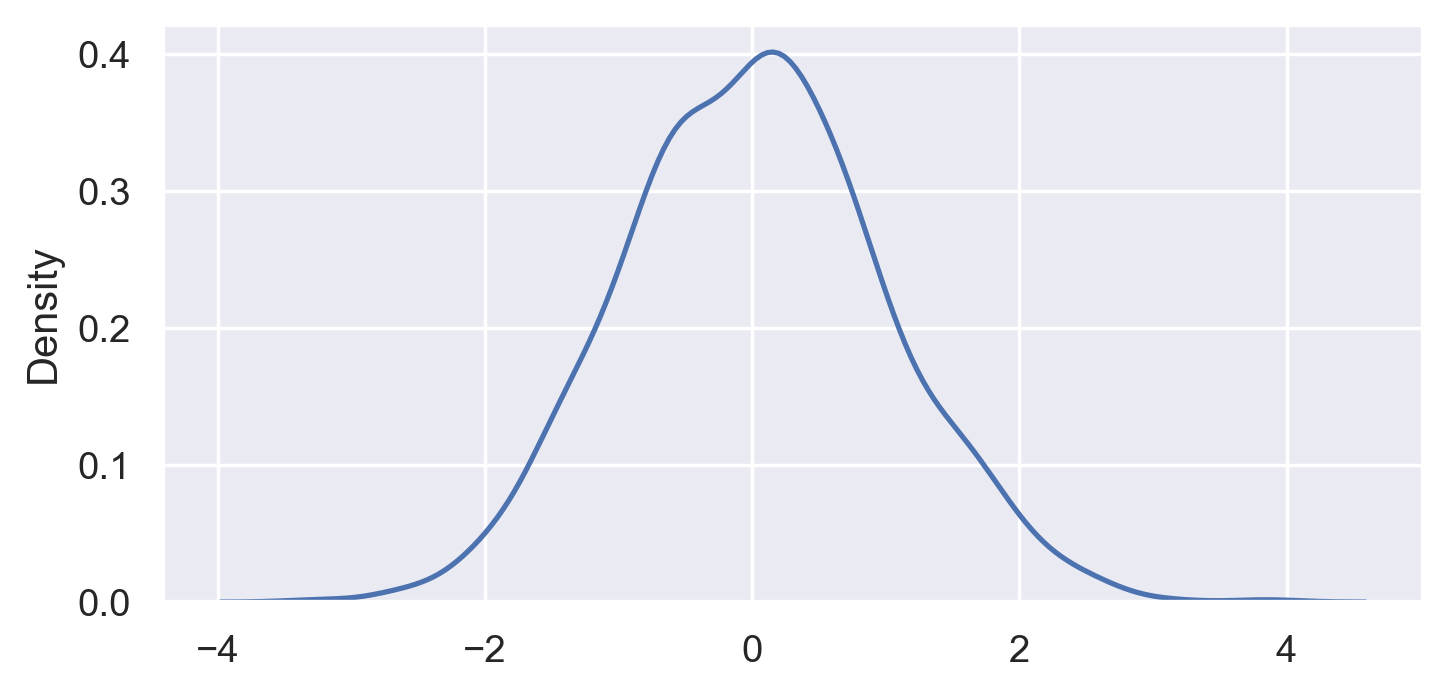

In [12]:
np.random.seed(42)

import matplotlib as mpl
with mpl.rc_context({"figure.dpi": 250}):
    plt.figure(figsize=(6.5, 3))
    sns.kdeplot(random.normal(size=1000))

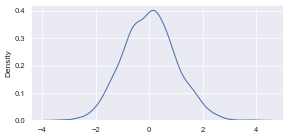

In [13]:
np.random.seed(42)

import matplotlib as mpl
with mpl.rc_context({"figure.dpi": 50}):
    plt.figure(figsize=(6.5, 3))
    sns.kdeplot(random.normal(size=1000))

### Binomial Distribution

A binomial distribution is a **discrete** probability distribution that models the number of successes in a fixed number of independent trials, where each trial has only two outcomes: “success” or “failure.” Every trial must have the same probability of success. This distribution is fundamental for analyzing repeated yes/no-type experiments (Bernoulli trials) and appears frequently in statistics and data science.

Key Features:
- There are `n` fixed trials.
- Each trial is **independent**.
- There are **only two possible outcomes** per trial (success or failure).
- The chance of success `p` is **constant** for each trial.

For example, flipping a fair coin 10 times and counting the number of heads. Here, each flip is **independent**, and the **probability** of heads (success) is **0.5**. The distribution of the number of heads follows a binomial distribution with `n=10`, `p=0.5`.


In [14]:
arr = np.random.choice([0, 1], size=10)
print(arr)
# count number of 1s in the array
print(np.sum(arr))

[0 1 0 1 0 0 0 0 1 0]
3


[6. 5. 7. 7. 3. 5. 5. 2. 5. 8. 7. 6. 4. 9. 4. 5. 2. 5. 7. 5. 3. 6. 6. 1.
 6. 4. 6. 7. 4. 6. 5. 5. 7. 1. 6. 3. 5. 2. 6. 7. 6. 5. 3. 3. 5. 6. 7. 2.
 8. 4. 5. 7. 6. 5. 3. 4. 4. 3. 8. 4. 4. 7. 7. 6. 5. 6. 6. 7. 7. 7. 3. 5.
 5. 6. 8. 4. 6. 7. 3. 7. 6. 5. 5. 1. 6. 5. 6. 5. 4. 5. 3. 3. 8. 6. 3. 7.
 6. 3. 4. 3.]


Text(0.5, 1.0, 'Seaborn')

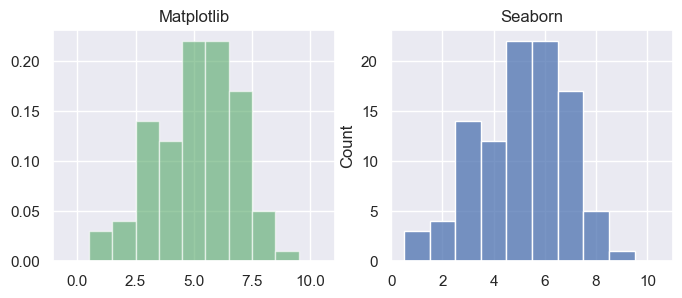

In [15]:
### create an empty array to store the number of 1s in each iteration
arr = np.array([])
for i in range(100):
    arr = np.append(arr, np.sum(np.random.choice([0, 1], size=10)))
print(arr)
### histogram of the number of 1s in each iteration
# sns.histplot(arr, kde=True)
# sns.histplot(arr, kde=True).figure.set_size_inches(6.5, 3)
# plt.subplots(figsize=(6.5, 3))
# plt.hist(arr, bins=np.arange(-0.5, 11.5, 1), density=True, alpha=0.6, color='g')

fig, ax = plt.subplots(1,2,figsize=(8, 3))
ax[0].hist(arr, alpha=0.6, color='g', bins=np.arange(-0.5, 11.5, 1), density=True)
sns.histplot(arr, bins=np.arange(0.5, 11.5, 1), ax=ax[1])

ax[0].set_title('Matplotlib')
ax[1].set_title('Seaborn')
# plt.tight_layout()

```{note}
To center each bin on a whole number (0.5→1.5 for 1, 1.5→2.5 for 2, etc.) to make both plots look consistent, use this general formula:

`
bins=np.arange(0.5, max(arr) + 1.5, 1) 
`
```


In [16]:
### test out 1 scaler
np.random.binomial(n=100, p=0.5, size=1)

array([53])

#### Central Limit Theorem

Note that the famous statistical result — the **Central Limit Theorem** (**CLT**) is in action when your sample size gets bigger, the **sample means** will approach **normal distribution**. You will see, e.g., the binomial distribution approaches a normal distribution as the number of trials (n) gets large. 

Looking at your plot below, when you have a large sample like 5000, both distributions are centered around 50 and have a very similar bell shape. This is especially true if you use KDE.


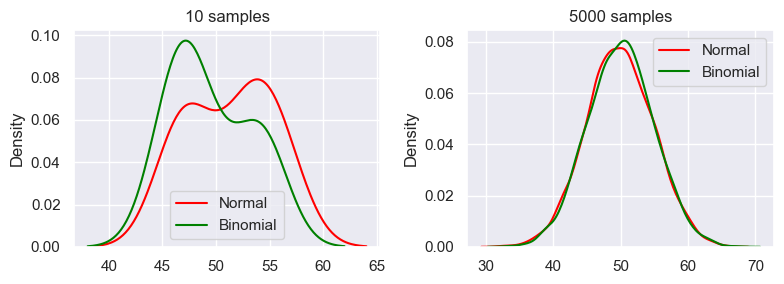

In [17]:
# binomial vs normal distributions
# np.random.seed(42)

norm_less = np.random.normal(loc=50, scale=5, size=10)    ### mean=50, SD=5 to match binomial
bino_less = np.random.binomial(n=100, p=0.5, size=10)    ### n= number of trials, p= probability of success, size= number of samples

norm_more = np.random.normal(loc=50, scale=5, size=5000)    ### mean=50, SD=5 to match binomial
bino_more = np.random.binomial(n=100, p=0.5, size=5000)    ### n= number of trials, p= probability of success, size= number of samples

fig, ax = plt.subplots(1, 2,figsize=(8, 3))
sns.kdeplot(data=norm_less, label='Normal', color='red', ax=ax[0])
sns.kdeplot(data=bino_less, label='Binomial', color='green', ax=ax[0])
sns.kdeplot(data=norm_more, label='Normal', color='red', ax=ax[1])
sns.kdeplot(data=bino_more, label='Binomial', color='green', ax=ax[1])
ax[0].set_title('10 samples')
ax[1].set_title('5000 samples')
ax[0].legend()
ax[1].legend()
plt.tight_layout()

Visually comparing normal distribution and binomial distribution. 


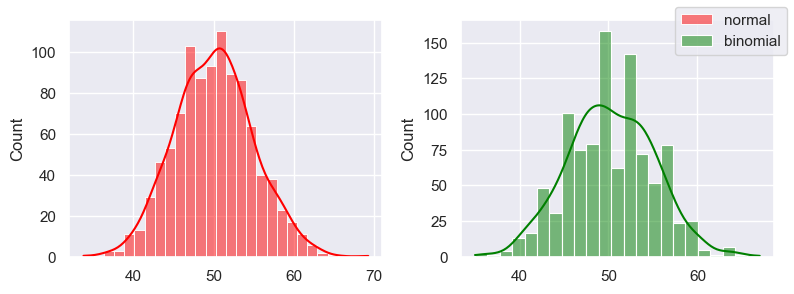

In [18]:
### normal distribution vs binomial
### binomial approximates normal distribution when n is big (np >=5)
### binomial "spikes" because it's integers

np.random.seed(42)
norm = np.random.normal(loc=50, scale=5, size=1000)     ### mean=50, SD=5 to match binomial
bino = np.random.binomial(n=100, p=0.5, size=1000)      ### n= number of trials (100), p= probability of success, 
                                                        ### size= number of samples (1000)

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
sns.histplot(norm, label='normal', color='red', ax=ax[0], kde=True)
sns.histplot(bino, label="binomial", color='green', ax=ax[1], kde=True)
fig.legend()
fig.tight_layout()

Coin flipping! These are the numbers generated and plotted in the green chart on the right. The `choice` function has the `size=` parameter, which is how many times you draw/pick from the coin array.


Number of Heads: 57


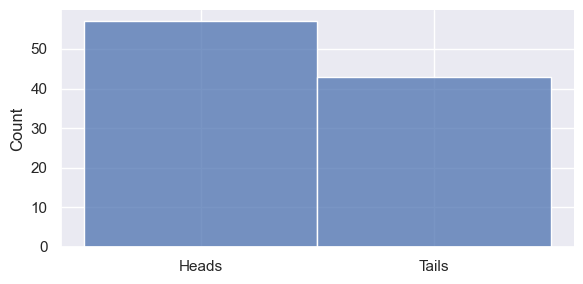

In [19]:
# Define the coin sides
coin = ['Heads', 'Tails']

# Simulate 100 coin flips
# np.random.seed(42)
flips = np.random.choice(coin, size=100)

# Count the number of heads
num_heads = np.count_nonzero(flips == 'Heads')

print("Number of Heads:", num_heads)

sns.displot(flips, height=3, aspect=2, bins=10, kde=False)  

### Uniform Distribution

A uniform distribution is a probability distribution where every outcome within a certain range is **equally likely** to occur. This means there is no bias—each result has the same probability as any other within the specified set. 

Examples: 
- Rolling a fair six-sided die. Each face (1 through 6) has a 1/6 chance of appearing, so the probability of rolling any particular number is equal.​
- Flipping a fair coin. Heads and tails each have a 50% chance.​



The `numpy.random.uniform()` method draws samples from a **uniform distribution**. Samples are uniformly distributed over the half-open interval ``[low, high)`` (includes low, but excludes high). In other words, any value within the given interval is equally likely to be drawn by `uniform`.

The syntax: 

`random.uniform(low=0.0, high=1.0, size=None)`


In [20]:
np.random.seed(42)

unif1 = np.random.uniform()                               ### return 1 number [0, 1)
unif2 = np.random.uniform(low=1, high=5, size=3)          ### return size=3 numbers [0, 1)
unif3 = np.random.uniform(low=5, high=10, size=(3, 3))    ### return a 3x3 2D array
unif4 = np.round(np.random.uniform(low=5, high=10, size=(3, 3)), 2)     ### rounded

unif5 = np.random.randint(low=5, high=10, size=(3, 3))    ### int

for unif in [ unif1, unif2, unif3, unif4, unif5 ]:
    print(unif, '\n')         

0.3745401188473625 

[4.80285723 3.92797577 3.39463394] 

[[5.7800932  5.7799726  5.29041806]
 [9.33088073 8.00557506 8.54036289]
 [5.10292247 9.84954926 9.1622132 ]] 

[[6.06 5.91 5.92]
 [6.52 7.62 7.16]
 [6.46 8.06 5.7 ]] 

[[8 8 7]
 [8 8 5]
 [7 9 7]] 



#### Best Example: Rolling Die

We eventually flip 1 many times here and see that all 6 numbers and have equal probability distribution.



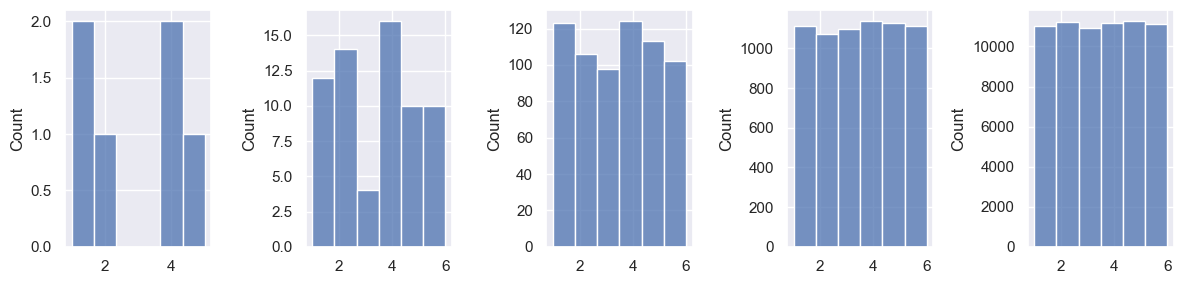

In [21]:
### flip for many times

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

flips = []
for i, ran in enumerate([ 6, 60, 600, 6000, 60000 ]):
    for flip in range(ran):                  ### if n > 26, print vertically
        # flips.append(random.randint(1, 7))
        flips.append(np.random.randint(1, 7))
    # sns.histplot(flips, ax=axes[i])
    sns.histplot(flips, ax=axes[i], bins=6)

plt.tight_layout()

Note that binning can affect the plotting greatly.


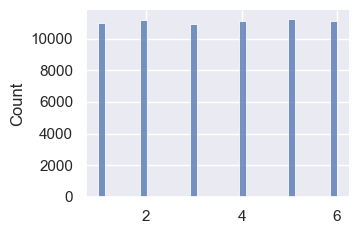

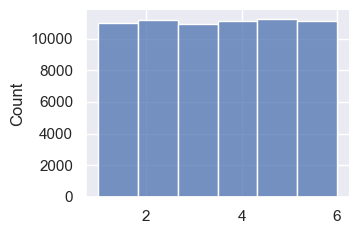

In [22]:
### displot with height and aspect

sns.displot(flips, height=2.5, aspect=3/2)
sns.displot(flips, height=2.5, aspect=3/2, bins=6)

Now use `randint()` to append a large number of random ints.


10000
1666.6666666666667


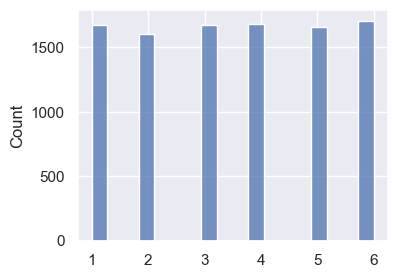

In [23]:
### flip for 1 million times
# random.seed(42)

flips2 = []
# for flip in range(1000000):   ### crash the kernel
for flip in range(10000):
    flips2.append(random.randint(1, 7))

plt.figure(figsize=(4, 3))
sns.histplot(flips2)

print(len(flips2))
print(len(flips2)/6)

Use the `random.uniform()` function to check. Looks uniform to me.


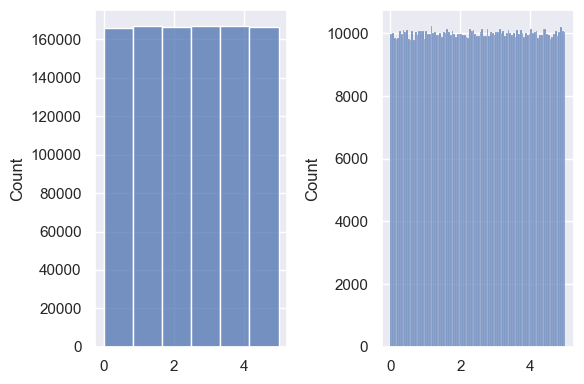

In [24]:
np.random.seed(42)
unif = np.random.uniform(0, 5, size=1000000)

fig, ax = plt.subplots(1, 2, figsize=(6, 4))

sns.histplot(data=unif, bins=6, ax=ax[0])
sns.histplot(data=unif, bins=100, ax=ax[1])

plt.tight_layout()

But, when we have smaller `n` and larger `bins`, we see spikes:


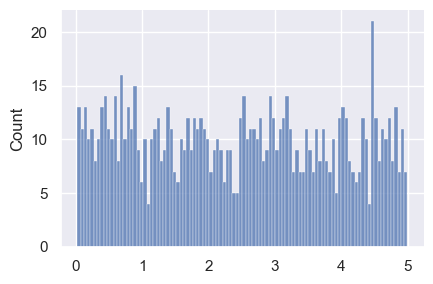

In [25]:
np.random.seed(42)
unif = np.random.uniform(0, 5, size=1000)    ### low, high exclusive
sns.displot(data=unif, kind='hist', height=3, aspect=3/2, bins=100)
# sns.displot(unif, kind='kde')
# plt.show()

Using scatter plot to visualize.


<Axes: >

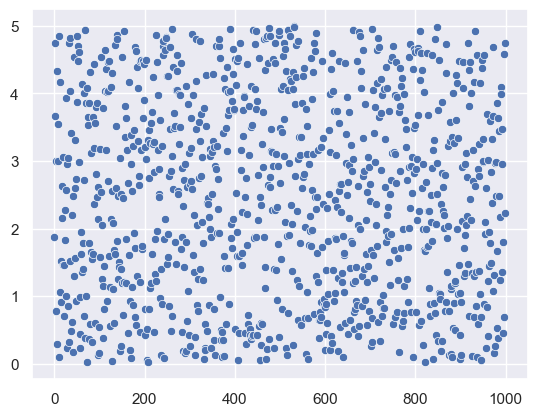

In [26]:
np.random.seed(42)
unif = np.random.uniform(0, 5, size=1000)

sns.scatterplot(data=unif)

<Axes: >

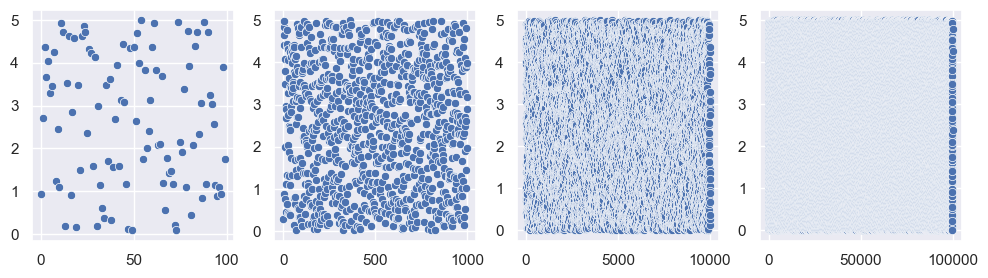

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3)) ### now we have one fig with two axes

unif1 = np.random.uniform(0, 5, size=100)
unif2 = np.random.uniform(0, 5, size=1000)
unif3 = np.random.uniform(0, 5, size=10000)
# unif4 = np.random.uniform(0, 5, size=10000000)  ### too big, will crash the kernel
unif4 = np.random.uniform(0, 5, size=100000)

sns.scatterplot(unif1, ax=axes[0])          
sns.scatterplot(unif2, ax=axes[1])
sns.scatterplot(unif3, ax=axes[2])
sns.scatterplot(unif4, ax=axes[3])


Now, produce a similar plot like the one above for `random.randn()`. Note the binning strategy here.


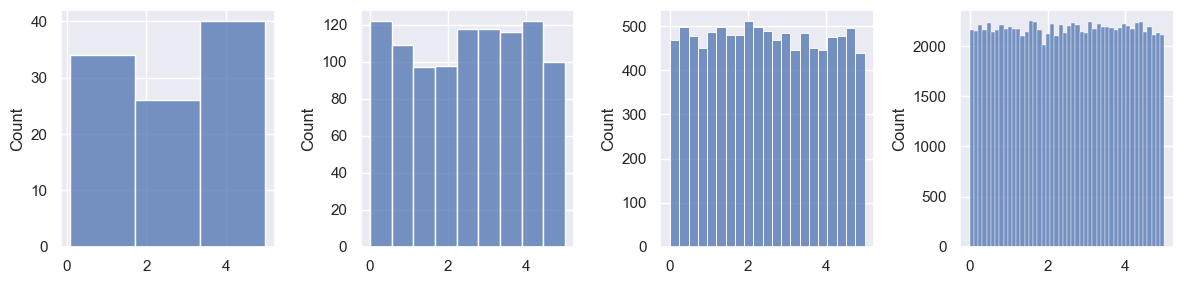

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3)) ### now we have one fig with two axes

datasets = [ unif1, unif2, unif3, unif4 ]
for i, data in enumerate(datasets):

    q25, q75 = np.percentile(data, [25, 75])            ### IQR: interquartile range, the difference between the 75th and 25th percentiles
    bin_width = 2 * (q75 - q25) * len(data) ** (-1/3)   ###  Freedman-Diaconis rule for bin width
    bins = int((data.max() - data.min()) / bin_width)   ### bins 
    
    sns.histplot(data=data, ax=axes[i], bins=bins)      ### plot

plt.tight_layout()


Visualizing using KDE.


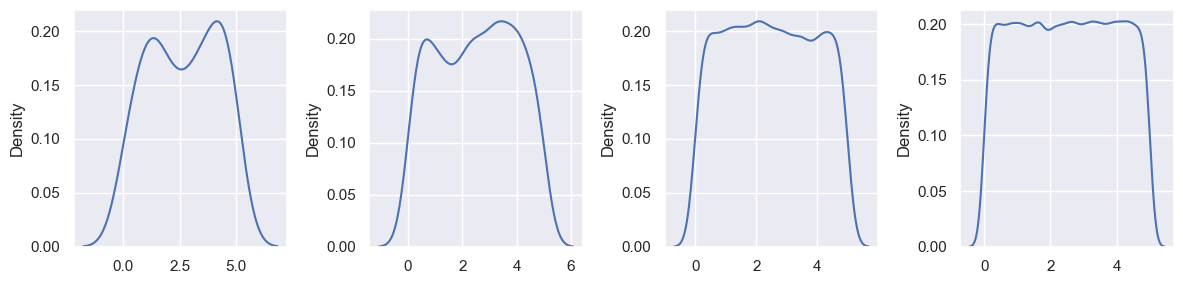

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3)) ### now we have one fig with two axes

for i, data in enumerate(datasets):

    ### bins ###
    q25, q75 = np.percentile(data, [25, 75])
    bin_width = 2 * (q75 - q25) * len(data) ** (-1/3)
    bins = int((data.max() - data.min()) / bin_width)   ### bins #
    
    sns.kdeplot(data=data, ax=axes[i])      ### plot

plt.tight_layout()

## The Law of Large Numbers

The law of large number says that **the more samples** you take, the closer your **sample mean** gets to the **true population mean**.

We'll simulate coin flips to show:
- Randomness
- Law of large numbers (the running average stabilizes)

Each flip is 0 (tails) or 1 (heads).


In [30]:
# random.seed(42)
tips.sample(5)

,total_bill,tip,sex,smoker,day,time,size
76,17.92,3.08,Male,Yes,Sat,Dinner,2
166,20.76,2.24,Male,No,Sun,Dinner,2
38,18.69,2.31,Male,No,Sat,Dinner,3
210,30.06,2.00,Male,Yes,Sat,Dinner,3
189,23.10,4.00,Male,Yes,Sun,Dinner,3


In [31]:
rng = np.random.default_rng(42)
# rng = np.random.default_rng()

type(rng.integers(0, 2, 10))
rng = np.random.default_rng(42) 
flips = rng.integers(0, 2, 200)
flips

array([0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1])

In [32]:
np.arange(len(flips)) + 1     ### fixed and grow linearly

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [33]:
flips.cumsum()                ### grow slower because of 0, 1

array([  0,   1,   2,   2,   2,   3,   3,   4,   4,   4,   5,   6,   7,
         8,   9,  10,  11,  11,  12,  12,  13,  13,  13,  14,  15,  16,
        16,  17,  18,  18,  18,  18,  18,  19,  20,  20,  21,  22,  22,
        23,  23,  24,  25,  25,  25,  26,  26,  27,  28,  29,  30,  30,
        30,  30,  30,  30,  31,  31,  32,  33,  34,  35,  35,  36,  36,
        36,  37,  37,  37,  37,  38,  38,  38,  38,  39,  39,  39,  39,
        40,  41,  42,  42,  42,  43,  44,  45,  45,  45,  46,  47,  47,
        48,  49,  49,  50,  50,  50,  51,  52,  52,  53,  53,  54,  54,
        55,  56,  57,  58,  58,  59,  59,  60,  61,  61,  62,  63,  63,
        63,  63,  63,  63,  64,  65,  65,  66,  67,  67,  68,  69,  70,
        71,  72,  72,  73,  74,  74,  75,  75,  75,  75,  76,  76,  76,
        76,  77,  78,  78,  78,  79,  79,  80,  80,  81,  81,  81,  82,
        82,  83,  84,  85,  86,  87,  87,  87,  87,  88,  88,  88,  88,
        88,  88,  88,  89,  90,  91,  91,  92,  92,  93,  94,  9

In [34]:
flips.cumsum() / (np.arange(len(flips)) + 1)  ### will get as big as about half of len() 

array([0.        , 0.5       , 0.66666667, 0.5       , 0.4       ,
       0.5       , 0.42857143, 0.5       , 0.44444444, 0.4       ,
       0.45454545, 0.5       , 0.53846154, 0.57142857, 0.6       ,
       0.625     , 0.64705882, 0.61111111, 0.63157895, 0.6       ,
       0.61904762, 0.59090909, 0.56521739, 0.58333333, 0.6       ,
       0.61538462, 0.59259259, 0.60714286, 0.62068966, 0.6       ,
       0.58064516, 0.5625    , 0.54545455, 0.55882353, 0.57142857,
       0.55555556, 0.56756757, 0.57894737, 0.56410256, 0.575     ,
       0.56097561, 0.57142857, 0.58139535, 0.56818182, 0.55555556,
       0.56521739, 0.55319149, 0.5625    , 0.57142857, 0.58      ,
       0.58823529, 0.57692308, 0.56603774, 0.55555556, 0.54545455,
       0.53571429, 0.54385965, 0.53448276, 0.54237288, 0.55      ,
       0.55737705, 0.56451613, 0.55555556, 0.5625    , 0.55384615,
       0.54545455, 0.55223881, 0.54411765, 0.53623188, 0.52857143,
       0.53521127, 0.52777778, 0.52054795, 0.51351351, 0.52   

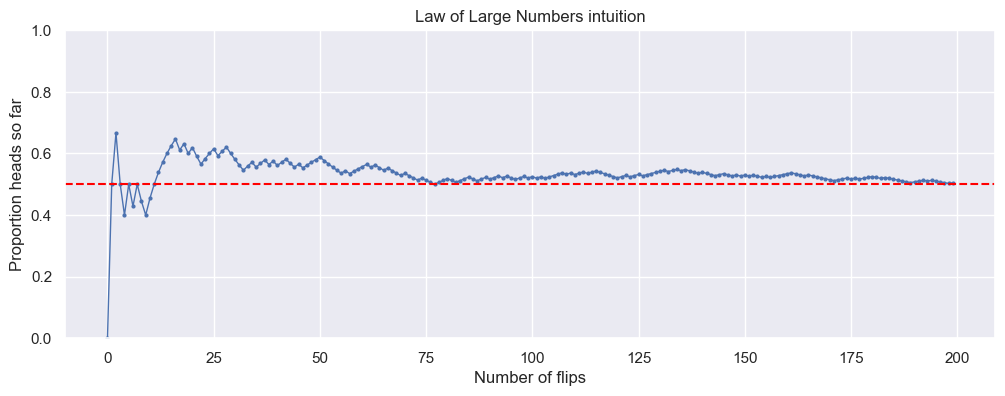

In [35]:
rng = np.random.default_rng(42)        ### random generator; seed: 42

flips = rng.integers(0, 2, size=200)   ### 200 0 or 1
running_prop = flips.cumsum() / (np.arange(len(flips)) + 1)     ### cumsum(): cumulative sum
                                                                ### output: an array
plt.figure(figsize=(12,4))
plt.plot(running_prop, marker='o', markersize=2, linewidth=1)   ### matplotlib.pyplot the array
plt.axhline(0.5, color='red', linestyle='--')
plt.xlabel('Number of flips')
plt.ylabel('Proportion heads so far')
plt.title('Law of Large Numbers intuition')
plt.ylim(0,1)
plt.show()

<!-- ## Terms to remember
- population / sample  
- variable / observation  
- distribution  
- mean / median / standard deviation / IQR  
- outlier / skew  
- probability / random event / independence  
- law of large numbers   -->


Dividing gives us the proportion of heads up to that point.

As you see, early on it bounces around wildly, but as n grows it converges toward 0.5 (the red dashed line), which is the Law of Large Numbers in action.



## Section Practice

Use this short exercise to check the main workflow from this section.


In [36]:
### Exercise: Compute Evidence for Descriptive Distributions
# Use the sample values below to summarize a small business metric.
# Calculate the mean and the distance between the largest and smallest values.
# Print both values.
values = [18, 21, 19, 25, 22]
### Your code starts here




### Your code ends here


In [37]:
### Solution
values = [18, 21, 19, 25, 22]
mean_value = sum(values) / len(values)
spread = max(values) - min(values)
print("Mean:", mean_value)
print("Spread:", spread)


Mean: 21.0
Spread: 7
